# Zadanie domowe -- interpolacja dwusześcienna

Interpolacja dwusześcienna, to podobnie jak w przypadku interpolacji dwuliniowej, rozszerzenie idei interpolacji jednowymiarowej na dwuwymiarową siatkę.
W trakcie jej obliczania wykorzystywane jest 16 pikseli z otoczenia (dla dwuliniowej 4).
Skutkuje to zwykle lepszymi wynikami - obraz wyjściowy jest bardziej gładki i z mniejszą liczbą artefaktów.
Ceną jest znaczny wzrost złożoności obliczeniowej (zostało to zaobserwowane podczas ćwiczenia).

Interpolacja dana jest wzorem:
\begin{equation}
I(i,j) = \sum_{i=0}^{3} \sum_{j=0}^{3} a_{ij} x^i y^j
\end{equation}

Zadanie sprowadza się zatem do wyznaczenia 16 współczynników $a_{ij}$.
W tym celu wykorzystuje się, oprócz wartość w puntach $A$ (0,0), $B$ (1 0), $C$ (1,1), $D$ (0,1) (por. rysunek dotyczący interpolacji dwuliniowej), także pochodne cząstkowe $A_x$, $A_y$, $A_{xy}$.
Pozwala to rozwiązać układ 16-tu równań.

Jeśli zgrupujemy parametry $a_{ij}$:
\begin{equation}
a = [ a_{00}~a_{10}~a_{20}~a_{30}~a_{01}~a_{11}~a_{21}~a_{31}~a_{02}~a_{12}~a_{22}~a_{32}~a_{03}~a_{13}~a_{23}~a_{33}]
\end{equation}

i przyjmiemy:
\begin{equation}
x = [A~B~D~C~A_x~B_x~D_x~C_x~A_y~B_y~D_y~C_y~A_{xy}~B_{xy}~D_{xy}~C_{xy}]^T
\end{equation}

To zagadnienie można opisać w postaci równania liniowego:
\begin{equation}
Aa = x
\end{equation}
gdzie macierz $A^{-1}$ dana jest wzorem:

\begin{equation}
A^{-1} =
\begin{bmatrix}
1& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0 \\
0&  0&  0&  0&  1&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0 \\
-3&  3&  0&  0& -2& -1&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0 \\
2& -2&  0&  0&  1&  1&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0 \\
0&  0&  0&  0&  0&  0&  0&  0&  1&  0&  0&  0&  0&  0&  0&  0 \\
0&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0&  1&  0&  0&  0 \\
0&  0&  0&  0&  0&  0&  0&  0& -3&  3&  0&  0& -2& -1&  0&  0 \\
0&  0&  0&  0&  0&  0&  0&  0&  2& -2&  0&  0&  1&  1&  0&  0 \\
-3&  0&  3&  0&  0&  0&  0&  0& -2&  0& -1&  0&  0&  0&  0&  0 \\
0&  0&  0&  0& -3&  0&  3&  0&  0&  0&  0&  0& -2&  0& -1&  0 \\
9& -9& -9&  9&  6&  3& -6& -3&  6& -6&  3& -3&  4&  2&  2&  1 \\
-6&  6&  6& -6& -3& -3&  3&  3& -4&  4& -2&  2& -2& -2& -1& -1 \\
2&  0& -2&  0&  0&  0&  0&  0&  1&  0&  1&  0&  0&  0&  0&  0 \\
0&  0&  0&  0&  2&  0& -2&  0&  0&  0&  0&  0&  1&  0&  1&  0 \\
-6&  6&  6& -6& -4& -2&  4&  2& -3&  3& -3&  3& -2& -1& -2& -1 \\
4& -4& -4&  4&  2&  2& -2& -2&  2& -2&  2& -2&  1&  1&  1&  1 \\
\end{bmatrix}
\end{equation}

Potrzebne w rozważaniach pochodne cząstkowe obliczane są wg. następującego przybliżenia (przykład dla punktu A):
\begin{equation}
A_x = \frac{I(i+1,j) - I(i-1,j)}{2}
\end{equation}
\begin{equation}
A_y = \frac{I(i,j+1) - I(i,j-1)}{2}
\end{equation}
\begin{equation}
A_{xy} = \frac{I(i+1,j+1) - I(i-1,j) - I(i,j-1) + I(i,j)}{4}
\end{equation}

## Zadanie

Wykorzystując podane informacje zaimplementuj interpolację dwusześcienną.
Uwagi:
- macierz $A^{-1}$ dostępna jest w pliku *a_invert.py*
- trzeba się zastanowić nad potencjalnym wykraczaniem poza zakres obrazka (jak zwykle).

Ponadto dokonaj porównania liczby operacji arytmetycznych i dostępów do pamięci koniecznych przy realizacji obu metod interpolacji: dwuliniowej i dwusześciennej.

In [ ]:
import cv2
import os
import requests
from matplotlib import pyplot as plt
import numpy as np

url = 'https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/'

fileName = "ainvert.py"
if not os.path.exists(fileName):
    r = requests.get(url + fileName, allow_redirects=True)
    open(fileName, 'wb').write(r.content)

#TODO Do samodzielnej implementacji

import ainvert




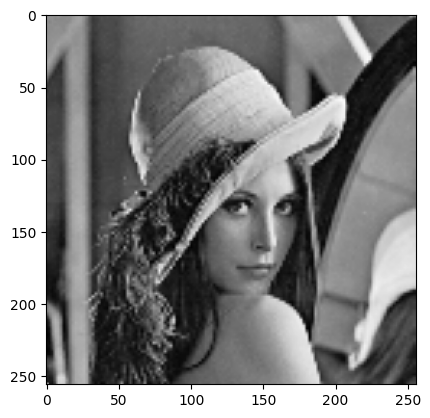

In [ ]:
url = 'https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/'
fileName = 'lena.bmp'
if not os.path.exists(fileName) :
    r = requests.get(url + fileName, allow_redirects=True)
    open(fileName, 'wb').write(r.content)

img = cv2.imread('lena.bmp', cv2.IMREAD_GRAYSCALE)
plt.imshow(img, 'gray')



In [ ]:
A_inv = np.array(ainvert.A_invert)
print(A_inv)

[[ 1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0]
 [-3  3  0  0 -2 -1  0  0  0  0  0  0  0  0  0  0]
 [ 2 -2  0  0  1  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0]
 [ 0  0  0  0  0  0  0  0 -3  3  0  0 -2 -1  0  0]
 [ 0  0  0  0  0  0  0  0  2 -2  0  0  1  1  0  0]
 [-3  0  3  0  0  0  0  0 -2  0 -1  0  0  0  0  0]
 [ 0  0  0  0 -3  0  3  0  0  0  0  0 -2  0 -1  0]
 [ 9 -9 -9  9  6  3 -6 -3  6 -6  3 -3  4  2  2  1]
 [-6  6  6 -6 -3 -3  3  3 -4  4 -2  2 -2 -2 -1 -1]
 [ 2  0 -2  0  0  0  0  0  1  0  1  0  0  0  0  0]
 [ 0  0  0  0  2  0 -2  0  0  0  0  0  1  0  1  0]
 [-6  6  6 -6 -4 -2  4  2 -3  3 -3  3 -2 -1 -2 -1]
 [ 4 -4 -4  4  2  2 -2 -2  2 -2  2 -2  1  1  1  1]]


In [ ]:
# NIE WYCHODZI POZA 255
def get_pixel_safe(img, i, j):
    h, w = img.shape
    i = min(int(i), h - 1)
    j = min(int(j), w - 1)


    return float(img[i, j])

In [ ]:
def compute_derivatives(img, x, y):

    I = lambda i, j: get_pixel_safe(img, int(i), int(j))

    A  = I(y,   x)
    B  = I(y,   x+1)
    D  = I(y+1, x)
    C  = I(y+1, x+1)


    # POCHODNE

    Ax = (I(y,   x+1) - I(y,   x-1)) / 2.0
    Bx = (I(y,   x+2) - I(y,   x))   / 2.0
    Dx = (I(y+1, x+1) - I(y+1, x-1)) / 2.0
    Cx = (I(y+1, x+2) - I(y+1, x))   / 2.0

    Ay = (I(y+1, x)   - I(y-1, x))   / 2.0
    By = (I(y+1, x+1) - I(y-1, x+1)) / 2.0
    Dy = (I(y+2, x)   - I(y,   x))   / 2.0
    Cy = (I(y+2, x+1) - I(y,   x+1)) / 2.0

    Axy = (I(y+1, x+1) - I(y+1, x-1) - I(y-1, x+1) + I(y-1, x-1)) / 4.0
    Bxy = (I(y+1, x+2) - I(y+1, x)   - I(y-1, x+2) + I(y-1, x))   / 4.0
    Dxy = (I(y+2, x+1) - I(y+2, x-1) - I(y,   x+1) + I(y,   x-1)) / 4.0
    Cxy = (I(y+2, x+2) - I(y+2, x)   - I(y,   x+2) + I(y,   x))   / 4.0

    return np.array([
        A, B, D, C,
        Ax, Bx, Dx, Cx,
        Ay, By, Dy, Cy,
        Axy, Bxy, Dxy, Cxy
    ], dtype=np.float64)

In [ ]:
def bicubic_interpolate(img, u, v):
    x = int(np.floor(u))
    y = int(np.floor(v))
    fx = u - x
    fy = v - y

    data_vec = compute_derivatives(img, x, y)

    a = A_inv @ data_vec

    # sum_{i=0}^3 sum_{j=0}^3 a_{ij} * fx^i * fy^j
    val = 0.0
    idx = 0
    for i in range(4):
        for j in range(4):
            val += a[idx] * (fx ** i) * (fy ** j)
            idx += 1

    return val

In [ ]:
def resize_bicubic(img, scale_factor):
    h, w = img.shape
    new_h = int(h * scale_factor)
    new_w = int(w * scale_factor)

    output = np.zeros((new_h, new_w), dtype=np.float64)

    for i in range(new_h):
        for j in range(new_w):
            u = j / scale_factor
            v = i / scale_factor
            output[i, j] = bicubic_interpolate(img, u, v)

    output = np.clip(output, 0, 255).astype(np.uint8)
    return output

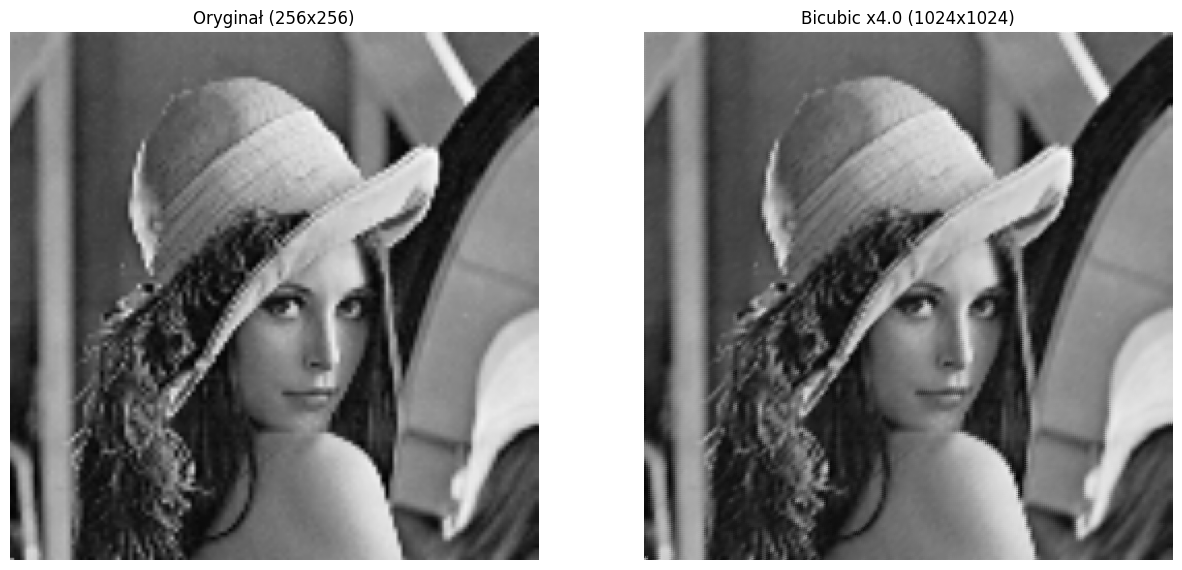

In [ ]:
scale = 4.0
img_bicubic = resize_bicubic(img, scale)

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.title(f"Oryginał ({img.shape[1]}x{img.shape[0]})")
plt.imshow(img, 'gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Bicubic x{scale} ({img_bicubic.shape[1]}x{img_bicubic.shape[0]})")
plt.imshow(img_bicubic, 'gray')
plt.axis('off')
plt.show()